# Exploração de SRAG — 2026

## Objetivo

Avaliar a estrutura, a cobertura e a qualidade da base para
o MVP do Sentinela, com foco em residentes de Minas Gerais.

## Fonte

- Sistema: SIVEP-Gripe.
- Arquivo: INFLUD26-28-09-2026.csv.
- Versão: 28/09/2026.

## Perguntas iniciais

- Quais campos estão disponíveis?
- Qual período está presente no arquivo?
- Quantos registros pertencem a residentes de MG?
- Quais valores ausentes e códigos precisam de atenção?

In [5]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

csv_path = (
    project_root
    / "data"
    / "raw"
    / "INFLUD26-28-09-2026.csv"
)

if not csv_path.is_file():
    raise FileNotFoundError(f"Arquivo não encontrado: {csv_path}")

print(f"Base selecionada: {csv_path.name}")

Base selecionada: INFLUD26-28-09-2026.csv


## 1. Leitura da amostra

Serão lidas as primeiras 1.000 linhas para conferir a estrutura.
Essa amostra não é aleatória e não representa necessariamente
a distribuição da base completa.

In [6]:
sample = pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    nrows=1_000,
)

expected_columns = [
    "SG_UF",
    "SG_UF_NOT",
    "DT_SIN_PRI",
    "SEM_PRI",
    "CLASSI_FIN",
    "HOSPITAL",
    "EVOLUCAO",
]

missing_columns = [
    column
    for column in expected_columns
    if column not in sample.columns
]

print(f"Linhas da amostra: {len(sample)}")
print(f"Quantidade de colunas: {len(sample.columns)}")
print(f"Campos esperados ausentes: {missing_columns}")

if missing_columns:
    raise ValueError(f"Campos não encontrados: {missing_columns}")

Linhas da amostra: 1000
Quantidade de colunas: 194
Campos esperados ausentes: []


In [7]:
selected_fields = sample[expected_columns].apply(
    lambda column: column.str.strip().replace("", pd.NA)
)

quality_summary = pd.DataFrame({
    "ausentes": selected_fields.isna().sum(),
    "percentual_ausente": (
        selected_fields.isna().mean() * 100
    ).round(2),
})

quality_summary.index.name = "campo"

quality_summary

,ausentes,percentual_ausente
campo,,
SG_UF,1,0.1
SG_UF_NOT,0,0.0
DT_SIN_PRI,0,0.0
SEM_PRI,0,0.0
CLASSI_FIN,117,11.7
HOSPITAL,31,3.1
EVOLUCAO,179,17.9


### Observações sobre a amostra

Nas primeiras 1.000 linhas:

- 1 registro não possui UF de residência.
- 117 não possuem classificação final.
- 31 não possuem informação de internação.
- 179 não possuem evolução preenchida.
- Não foram encontrados valores ausentes em DT_SIN_PRI e SEM_PRI.

Esses resultados pertencem à amostra nacional inicial.
Não representam a base completa nem especificamente Minas Gerais.

Valores ausentes serão mantidos separados dos códigos de resposta.

## 2. Classificação, internação e evolução — Minas Gerais

Contagem dos valores de CLASSI_FIN, HOSPITAL e EVOLUCAO
para registros com SG_UF igual a MG.

A leitura será realizada em blocos, preservando valores ausentes.

In [8]:
from collections import Counter

fields_to_check = ["CLASSI_FIN", "HOSPITAL", "EVOLUCAO"]
counts = {field: Counter() for field in fields_to_check}

total_mg = 0

for chunk in pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    usecols=["SG_UF", *fields_to_check],
    chunksize=50_000,
):
    is_mg = (
        chunk["SG_UF"]
        .str.strip()
        .str.upper()
        .eq("MG")
        .fillna(False)
    )

    mg_records = chunk.loc[is_mg]
    total_mg += len(mg_records)

    for field in fields_to_check:
        values = (
            mg_records[field]
            .str.strip()
            .replace("", pd.NA)
            .fillna("AUSENTE")
        )

        counts[field].update(values.tolist())

rows = []

for field, field_counts in counts.items():
    assert sum(field_counts.values()) == total_mg

    for value, quantity in sorted(field_counts.items()):
        rows.append({
            "campo": field,
            "valor": value,
            "quantidade": quantity,
            "percentual": (
                round(quantity / total_mg * 100, 2)
                if total_mg else 0
            ),
        })

code_summary = pd.DataFrame(rows)

print(f"Total de linhas de residentes em MG: {total_mg}")
code_summary

Total de linhas de residentes em MG: 29087


,campo,valor,quantidade,percentual
0,CLASSI_FIN,1,3211,11.04
1,CLASSI_FIN,2,7196,24.74
2,CLASSI_FIN,3,363,1.25
3,CLASSI_FIN,4,16533,56.84
4,CLASSI_FIN,5,487,1.67
5,CLASSI_FIN,AUSENTE,1297,4.46
6,HOSPITAL,1,28227,97.04
7,HOSPITAL,2,349,1.20
8,HOSPITAL,9,10,0.03
9,HOSPITAL,AUSENTE,501,1.72


### Resultados — classificação, internação e evolução em MG

Foram analisadas 29.087 linhas de residentes em Minas Gerais.

Os códigos observados em CLASSI_FIN, HOSPITAL e EVOLUCAO
correspondem às categorias do dicionário consultado.
Essa conferência não valida a compatibilidade de todos os
campos da base de 2026.

Principais resultados:

- CLASSI_FIN: 1.297 valores ausentes (4,46%).
- SRAG não especificada: 16.533 registros (56,84%),
  mantidos separados da classificação ausente.
- HOSPITAL: 28.227 registros com internação (97,04%),
  349 sem internação, 10 ignorados e 501 ausentes.
- EVOLUCAO: 3.062 valores ausentes (10,53%).

Os percentuais descrevem as linhas do arquivo, sem avaliação
de duplicidades ou aplicação dos critérios finais de inclusão.

Valores ausentes não serão substituídos por respostas negativas
ou pelo código de informação ignorada.

In [9]:
hospital_evolution_counts = Counter()

for chunk in pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    usecols=["SG_UF", "HOSPITAL", "EVOLUCAO"],
    chunksize=50_000,
):
    is_mg =(
        chunk["SG_UF"]
        .str.strip()
        .str.upper()
        .eq("MG")
        .fillna(False)
    )

    mg_records = chunk.loc[is_mg]

    hospital = (
        mg_records["HOSPITAL"]
        .str.strip()
        .replace("", pd.NA)
        .fillna("AUSENTE")
    )

    evolution = (
        mg_records["EVOLUCAO"]
        .str.strip()
        .replace("", pd.NA)
        .fillna("AUSENTE")
    )
    
    hospital_evolution_counts.update(zip(hospital, evolution))

cross_rows = [
    {
        "hospital": hospital,
        "evolucao": evolution,
        "quantidade": quantity,
    }
    for (hospital, evolution), quantity
    in hospital_evolution_counts.items()
]

cross_table = (
    pd.DataFrame(cross_rows)
    .pivot(
        index="hospital",
        columns="evolucao",
        values="quantidade",
    )
    .fillna(0)
    .astype("int64")
    .sort_index()
    .sort_index(axis=1)
)

assert cross_table.to_numpy().sum() == total_mg

cross_table

evolucao,1,2,3,9,AUSENTE
hospital,,,,,
1,22883,1375,603,602,2764
2,279,12,0,16,42
9,5,0,2,1,2
AUSENTE,167,4,11,65,254


### Cruzamento entre internação e evolução

O cruzamento contabilizou as 29.087 linhas de residentes em MG.

Foram identificadas:
- 12 linhas sem internação informada como realizada e com
  evolução de óbito (HOSPITAL = 2 e EVOLUCAO = 2).
- 4 linhas com internação ausente e evolução de óbito.
- 2.764 linhas com internação e evolução ausente.

As combinações serão avaliadas junto aos critérios oficiais
de inclusão. Nenhuma categoria foi excluída nesta exploração.

A tabela não permite determinar, isoladamente, se uma combinação
representa erro de preenchimento.

In [10]:
notification_parts = []

for chunk in pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    usecols=["SG_UF", "NU_NOTIFIC"],
    chunksize=50_000,
):
    is_mg =(
        chunk["SG_UF"]
        .str.strip()
        .str.upper()
        .eq("MG")
        .fillna(False)
    )

    identifiers = (
        chunk.loc[is_mg, "NU_NOTIFIC"]
        .str.strip()
        .replace("", pd.NA)
    )

    notification_parts.append(identifiers)

notification_ids = pd.concat(
    notification_parts,
    ignore_index=True,
)

frequencies = notification_ids.dropna().value_counts()
repeated_ids = frequencies[frequencies > 1]

identifier_summary = pd.Series({
    "linhas_mg": len(notification_ids),
    "numero_notificacao_ausente": int(notification_ids.isna().sum()),
    "numeros_distintos_preenchidos": len(frequencies),
    "numero_com_mais_de_uma_ocorrencia": len(repeated_ids),
    "lnhas_com_numeros_repetidos": int(repeated_ids.sum())
}, name="quantidade")

assert len(notification_ids) == total_mg

identifier_summary.to_frame()

,quantidade
linhas_mg,29087
numero_notificacao_ausente,0
numeros_distintos_preenchidos,29087
numero_com_mais_de_uma_ocorrencia,0
lnhas_com_numeros_repetidos,0


### Número de notificação — Minas Gerais

Nas 29.087 linhas de residentes em MG:

- Todos os números de notificação estão preenchidos.
- Foram encontrados 29.087 números distintos.
- Nenhum número apresentou mais de uma ocorrência.

Não será aplicada remoção de linhas por repetição de NU_NOTIFIC,
pois nenhuma repetição foi identificada neste recorte.

Essa verificação não identifica possíveis notificações de uma
mesma pessoa ou episódio registradas com números diferentes.

In [11]:
sample_mg = sample.loc[
    sample["SG_UF"]
    .str.strip()
    .str.upper()
    .eq("MG")
    .fillna(False)
]

sample_mg[["DT_SIN_PRI", "SEM_PRI"]].head(10)

,DT_SIN_PRI,SEM_PRI
16,2026-05-15T00:00:00.000Z,20
22,2026-04-19T00:00:00.000Z,17
29,2026-05-16T00:00:00.000Z,20
60,2026-04-19T00:00:00.000Z,17
68,2026-04-18T00:00:00.000Z,16
86,2026-07-05T00:00:00.000Z,28
118,2026-07-12T00:00:00.000Z,29
131,2026-03-11T00:00:00.000Z,11
139,2026-05-08T00:00:00.000Z,19
141,2026-02-01T00:00:00.000Z,06


## 3. Distribuição semanal — Minas Gerais

Os registros serão agrupados pelo campo SEM_PRI da fonte.

Serão verificados valores ausentes, não numéricos, fracionários
e fora do intervalo de 1 a 53.

Essa validação verifica o formato do campo, mas ainda não
confirma sua correspondência com a data de início dos sintomas.

In [12]:
calendar_comparison = Counter()
comparison_total_mg = 0

official_start_2026 = pd.Timestamp("2026-01-04", tz="UTC")
official_end_2026 = pd.Timestamp("2027-01-03", tz="UTC")
official_week_counts = Counter()

for comparison_chunk in pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    usecols=["SG_UF", "DT_SIN_PRI", "SEM_PRI"],
    chunksize=50_000,
):
    mg_mask = (
        comparison_chunk["SG_UF"]
        .str.strip()
        .str.upper()
        .eq("MG")
        .fillna(False)
    )

    comparison_mg = comparison_chunk.loc[mg_mask]
    comparison_total_mg += len(comparison_mg)

    comparison_dates = pd.to_datetime(
        comparison_mg["DT_SIN_PRI"].str.strip(),
        format="ISO8601",
        utc=True,
        errors="coerce",
    ).dt.normalize()

    source_weeks = pd.to_numeric(
        comparison_mg["SEM_PRI"].str.strip(),
        errors="coerce",
    )

    dates_ok = (
        comparison_dates.notna()
        & comparison_dates.ge(official_start_2026)
        & comparison_dates.lt(official_end_2026)
    ).fillna(False)

    weeks_ok = (
        source_weeks.notna()
        & source_weeks.between(1, 53)
        & source_weeks.mod(1).eq(0)
    ).fillna(False)

    comparable_mask = dates_ok & weeks_ok

    official_weeks = (
        (
            comparison_dates.loc[comparable_mask]
            - official_start_2026
        ).dt.days // 7
    ) + 1

    official_week_counts.update(
        official_weeks.astype("int64").tolist()
    )

    differences = (
        source_weeks.loc[comparable_mask] - official_weeks
    ).astype("int64")

    calendar_comparison.update(differences.tolist())
    calendar_comparison["NAO_COMPARAVEL"] += int(
        (~comparable_mask).sum()
    )

comparison_result = pd.DataFrame([
    {
        "diferenca_informada_menos_oficial": str(difference),
        "registros": quantity,
    }
    for difference, quantity in calendar_comparison.items()
])

official_weekly_summary = pd.DataFrame(
    sorted(official_week_counts.items()),
    columns=["semana_epidemiologica_calculada", "registros"]
)

assert comparison_result["registros"].sum() == comparison_total_mg
assert (
    official_weekly_summary["registros"].sum()
    == comparison_total_mg
)

print(f"Total de linhas de MG: {comparison_total_mg}")
comparison_result

official_weekly_summary
probe = pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    usecols=["SG_UF", "DT_SIN_PRI", "SEM_PRI"],
    nrows=1_000,
)

probe = probe.loc[
    probe["SG_UF"].str.strip().str.upper().eq("MG").fillna(False)
].copy()

parsed_dates = pd.to_datetime(
    probe["DT_SIN_PRI"].str.strip(),
    format="ISO8601",
    utc=True,
    errors="coerce",
).dt.normalize()

parsed_weeks = pd.to_numeric(
    probe["SEM_PRI"].str.strip(),
    errors="coerce",
)

date_in_calendar = (
    parsed_dates.ge(pd.Timestamp("2026-01-04", tz="UTC"))
    & parsed_dates.lt(pd.Timestamp("2027-01-03", tz="UTC"))
)

week_valid = (
    parsed_weeks.notna()
    & parsed_weeks.between(1, 53)
    & parsed_weeks.mod(1).eq(0)
).fillna(False)

print(f"Arquivo: {csv_path.name}")
print(f"Linhas de MG na amostra: {len(probe)}")
print(f"Datas convertidas: {parsed_dates.notna().sum()}")
print(f"Datas dentro do calendário: {date_in_calendar.sum()}")
print(f"Semanas válidas: {week_valid.sum()}")
print(f"Linhas comparáveis: {(date_in_calendar & week_valid).sum()}")

diagnostic = pd.DataFrame({
    "data_original": probe["DT_SIN_PRI"],
    "data_convertida": parsed_dates,
    "semana_original": probe["SEM_PRI"],
    "semana_convertida": parsed_weeks,
    "data_no_calendario": date_in_calendar,
    "semana_valida": week_valid,
})

diagnostic.head(5)

Total de linhas de MG: 29087
Arquivo: INFLUD26-28-09-2026.csv
Linhas de MG na amostra: 145
Datas convertidas: 145
Datas dentro do calendário: 145
Semanas válidas: 145
Linhas comparáveis: 145


,data_original,data_convertida,semana_original,semana_convertida,data_no_calendario,semana_valida
16,2026-05-15T00:00:00.000Z,2026-05-15 00:00:00+00:00,20,20,True,True
22,2026-04-19T00:00:00.000Z,2026-04-19 00:00:00+00:00,17,17,True,True
29,2026-05-16T00:00:00.000Z,2026-05-16 00:00:00+00:00,20,20,True,True
60,2026-04-19T00:00:00.000Z,2026-04-19 00:00:00+00:00,17,17,True,True
68,2026-04-18T00:00:00.000Z,2026-04-18 00:00:00+00:00,16,16,True,True


In [13]:
weekly_counts = Counter()

weekly_total_mg = 0
missing_week = 0
invalid_week = 0

for chunk in pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    usecols=["SG_UF", "SEM_PRI"],
    chunksize=50_000,
):
    is_mg = (
        chunk["SG_UF"]
        .str.strip()
        .str.upper()
        .eq("MG")
        .fillna(False)
    )

    raw_week = (
        chunk.loc[is_mg, "SEM_PRI"]
        .str.strip()
        .replace("", pd.NA)
    )

    weekly_total_mg += len(raw_week)

    week = pd.to_numeric(raw_week, errors="coerce")

    valid_week = (
        week.notna()
        & week.between(1, 53)
        & week.mod(1).eq(0)
    ).fillna(False)

    missing_week += int(raw_week.isna().sum())
    invalid_week += int(
        (raw_week.notna() & ~valid_week).sum()
    )

    weekly_counts.update(
        week.loc[valid_week].astype("int64").tolist()
    )

weekly_summary = pd.DataFrame(
    sorted(weekly_counts.items()),
    columns=["semana_epidemiologica", "registros"]
)

counted_rows = sum(weekly_counts.values())

assert (
    counted_rows + missing_week + invalid_week
    == weekly_total_mg
)

print(f"Total de linhas de MG: {weekly_total_mg}")
print(f"Linhas agrupadas: {counted_rows}")
print(f"Semana ausente: {missing_week}")
print(f"Semana inválida: {invalid_week}")

weekly_summary

Total de linhas de MG: 29087
Linhas agrupadas: 29087
Semana ausente: 0
Semana inválida: 0


,semana_epidemiologica,registros
0,2,436
1,3,415
2,4,376
3,5,367
4,6,388
5,7,494
6,8,559
7,9,550
8,10,735
9,11,754


### Distribuição pelo calendário oficial

A semana epidemiológica foi calculada a partir de DT_SIN_PRI,
utilizando o calendário oficial de 2026.

- 29.087 linhas agrupadas.
- Semanas observadas: 1 a 38.
- Maior contagem observada: semana 24, com 1.247 registros.
- Semana 38: 102 registros na versão consultada.

As contagens representam notificações presentes no arquivo.
A queda recente não será interpretada como redução da transmissão
sem avaliar atrasos e revisões.

In [14]:
delay_parts = []

for delay_chunk in pd.read_csv(
    csv_path,
    sep=";",
    encoding="utf-8-sig",
    dtype="string",
    usecols=["SG_UF", "DT_SIN_PRI", "DT_NOTIFIC"],
    chunksize=50_000,
):
    is_mg = (
        delay_chunk["SG_UF"]
        .str.strip()
        .str.upper()
        .eq("MG")
        .fillna(False)
    )

    mg_delay = delay_chunk.loc[is_mg]

    symptom_date = pd.to_datetime(
        mg_delay["DT_SIN_PRI"].str.strip(),
        format="ISO8601",
        utc=True,
        errors="coerce",
    ).dt.normalize()

    notification_date = pd.to_datetime(
        mg_delay["DT_NOTIFIC"].str.strip(),
        format="ISO8601",
        utc=True,
        errors="coerce",
    ).dt.normalize()

    delay_parts.append(pd.DataFrame({
        "data_sintomas": symptom_date,
        "data_notificacao": notification_date,
        "intervalo_dias": (
            notification_date - symptom_date
        ).dt.days,
    }))

delay_data = pd.concat(delay_parts, ignore_index=True)

assert len(delay_data) == comparison_total_mg

delay = delay_data["intervalo_dias"]
nonnegative_delay = delay.loc[delay.notna() & delay.ge(0)]

print(f"Linhas de MG: {len(delay_data)}")
print(
    "Data de notificação ausente ou não convertida: "
    f"{delay_data['data_notificacao'].isna().sum()}"
)
print(f"Intervalos não calculáveis: {delay.isna().sum()}")
print(f"Intervalos negativos {delay.lt(0).sum()}")

nonnegative_delay.describe(percentiles=[0.5, 0.9, 0.95]).to_frame()


Linhas de MG: 29087
Data de notificação ausente ou não convertida: 0
Intervalos não calculáveis: 0
Intervalos negativos 0


,intervalo_dias
count,29087.000000
mean,5.683020
std,8.909944
min,0.000000
50%,4.000000
90%,11.000000
95%,17.000000
max,160.000000


### Intervalo entre sintomas e notificação — MG

Foram avaliadas 29.087 linhas.

- Nenhuma data de notificação ausente ou não convertida.
- Nenhum intervalo não calculável ou negativo.
- Média: 5,68 dias.
- Mediana: 4 dias.
- Percentil 90: 11 dias.
- Percentil 95: 17 dias.
- Máximo: 160 dias.

Os resultados descrevem apenas notificações presentes
na versão de 28/09/2026.

Esse intervalo não mede todo o atraso até a publicação
nem garante a completude das semanas recentes.

O intervalo máximo será investigado antes de ser tratado
como erro ou excluído.

## Conclusão da exploração inicial

### Base avaliada

- Arquivo: INFLUD26-28-09-2026.csv.
- Versão: 28/09/2026.
- Total nacional: 220.941 linhas.
- Recorte: residentes em Minas Gerais, usando SG_UF = MG.
- Total no recorte: 29.087 linhas.

### Verificações realizadas

- Campos necessários à exploração presentes.
- Datas de início dos sintomas convertidas sem falhas.
- Todas as datas de início dos sintomas pertencem a 2026.
- Nenhum número de notificação ausente ou repetido no recorte.
- Códigos observados em CLASSI_FIN, HOSPITAL e EVOLUCAO
  correspondem às categorias do dicionário consultado.
- Valores ausentes mantidos separados do código “Ignorado”.
- Intervalos entre sintomas e notificação calculáveis
  e não negativos em todas as linhas de MG.

### Divergência temporal

SEM_PRI está uma semana acima da semana correspondente
no calendário oficial de 2026 em todas as linhas de MG.

O campo original foi preservado. Uma semana calculada
a partir de DT_SIN_PRI foi utilizada na exploração.

A causa da divergência ainda precisa ser esclarecida.
A regra utilizada não deverá ser aplicada automaticamente
a outros anos.

### Limitações

- Unicidade de NU_NOTIFIC não garante ausência de notificações
  de um mesmo episódio com números diferentes.
- Datas convertíveis não garantem correção epidemiológica.
- As contagens representam linhas da base, sem aplicação
  dos critérios finais de inclusão.
- Semanas recentes podem receber notificações e revisões.
- O intervalo até a notificação não mede todo o atraso
  até a publicação.
- Um único ano não é suficiente para definir a referência
  histórica do sistema de alertas.

### Avaliação de viabilidade

A base permite continuar o desenvolvimento exploratório
do recorte estadual de SRAG em Minas Gerais.

Essa avaliação não significa que os dados estejam prontos
para gerar alertas epidemiológicos.

### Pendências

- Confirmar condições de uso específicas dos dados.
- Esclarecer a divergência de SEM_PRI.
- Definir critérios de inclusão com documentação oficial.
- Avaliar o intervalo máximo de 160 dias.
- Avaliar compatibilidade e comparabilidade dos anos históricos.

## Validação da exportação

Conferência do arquivo processado em relação aos resultados
da exploração e ao relatório da execução.

In [15]:
import json

processed_path = (
    project_root / "data" / "processed" / "srag_2026_mg.csv"
)

report_path = (
    project_root / "data" / "processed" / "srag_2026_mg_report.json"
)

processed = pd.read_csv(
    processed_path,
    sep=";",
    encoding="utf-8",
    dtype="string",
)

report = json.loads(report_path.read_text(encoding="utf-8"))

required_output_columns = [
    *expected_columns,
    "NU_NOTIFIC",
    "DT_NOTIFIC",
    "DT_SIN_PRI_PARSED",
    "DT_NOTIFIC_PARSED",
]

missing_output_columns = sorted(
    set(required_output_columns) - set(processed.columns)
)

assert not missing_output_columns, missing_output_columns
assert len(processed) == report["selected_rows"] == 29_087

residence_uf = processed["SG_UF"].str.strip().str.upper()
assert residence_uf.eq("MG").fillna(False).all()

assert processed["NU_NOTIFIC"].notna().all()
assert processed["NU_NOTIFIC"].str.strip().nunique() == len(processed)


for original, converted in [
    ("DT_SIN_PRI", "DT_SIN_PRI_PARSED"),
    ("DT_NOTIFIC", "DT_NOTIFIC_PARSED"),
]:
    original_dates = pd.to_datetime(
        processed[original],
        format="ISO8601",
        utc=True,
        errors="coerce",
    )

    exported_dates = pd.to_datetime(
        processed[converted],
        format="ISO8601",
        utc=True,
        errors="coerce",
    )

    assert original_dates.notna().all(), original
    assert exported_dates.notna().all(), converted
    assert original_dates.eq(exported_dates).all(), converted

print(f"Linhas conferidas: {len(processed)}")
print(f"Colunas: {len(processed.columns)}")
print("Recorte de MG confirmado.")
print("Números de notificação únicos.")
print("Datas exportadas correspondem aos campos originais.")

Linhas conferidas: 29087
Colunas: 11
Recorte de MG confirmado.
Números de notificação únicos.
Datas exportadas correspondem aos campos originais.


In [16]:
calendar_output = pd.read_csv(
    project_root / "data" / "processed" / "srag_2026_mg_calendar.csv",
    sep=";",
    dtype="string",
)

calculated_year = pd.to_numeric(
    calendar_output["EPI_YEAR_CALCULATED"],
    errors="coerce",
)

calculated_week = pd.to_numeric(
    calendar_output["EPI_WEEK_CALCULATED"],
    errors="coerce"
)

source_week = pd.to_numeric(
    calendar_output["SEM_PRI"],
    errors="coerce",
)

assert len(calendar_output) == 29_087
assert calculated_year.eq(2026).fillna(False).all()
assert calculated_week.notna().all()
assert calculated_week.between(1, 52).fillna(False).all()
assert (source_week - calculated_week).eq(1).fillna(False).all()

print(f"Linhas: {len(calendar_output)}")
print(f"Colunas: {len(calendar_output.columns)}")
print(f"Semana mínima: {calculated_week.min()}")
print(f"Semana máxima: {calculated_week.max()}")
print("Diferença de +1 em SEM_PRI confirmada.")

Linhas: 29087
Colunas: 13
Semana mínima: 1
Semana máxima: 38
Diferença de +1 em SEM_PRI confirmada.


In [17]:
normalized_output = pd.read_csv(
    project_root / "data" / "processed" / "srag_2026_mg_normalized.csv",
    sep=";",
    dtype="string",
)

expected_uf = (
    normalized_output["SG_UF"]
    .str.strip()
    .str.upper()
    .replace("", pd.NA)
)

assert len(normalized_output) == 29_087
assert normalized_output["RESIDENCE_UF_NORMALIZED"].eq(
    expected_uf
).fillna(False).all()

assert normalized_output["RESIDENCE_UF_NORMALIZED"].eq(
    "MG"
).fillna(False).all()

print(f"Linhas: {len(normalized_output)}")
print(f"Colunas: {len(normalized_output.columns)}")
print("UF padronizada conferida com o campo original.")

Linhas: 29087
Colunas: 14
UF padronizada conferida com o campo original.


In [18]:
report_path = (
    project_root / "data" / "processed" / "srag_2026_mg_v2_report.json"
)

report = json.loads(report_path.read_text(encoding="utf-8"))

assert report["total_rows"] == 220_941
assert report["selected_rows"] == 29_087
assert all(value == 0 for value in report["date_validation"].values())

assert report["export"]["status"] == "completed"
assert report["export"]["exported_rows"] == 29_087
assert len(report["export"]["derived_columns"]) == 5

assert report["calendar_transformation"]["reference"] == (
    "https://portalsinan.saude.gov.br/calendario-epidemiologico"
)

print("Relatório JSON conferido.")

Relatório JSON conferido.


In [22]:
import json

report_path = (
    project_root
    / "data"
    / "processed"
    / "srag_2026_mg_calendar_check_report.json"
)

report = json.loads(report_path.read_text(encoding="utf-8"))
calendar_validation = report["calendar_validation"]

expected = {
    "rows_checked": 29_087,
    "calculated_week_missing": 0,
    "source_week_missing_or_invalid": 0,
    "not_comparable": 0,
    "matching": 0,
    "source_one_week_ahead": 29_087,
    "other_differences": 0,
}

assert report["selected_rows"] == expected["rows_checked"]

for indicator, expected_value in expected.items():
    actual_value = calendar_validation[indicator]

    assert actual_value == expected_value, (
        f"{indicator}: esperado={expected_value}, "
        f"encontrado={actual_value}"
    )

print("Validação do calendário conferida.")

pd.DataFrame({
    "encontrado": calendar_validation,
    "esperado": expected,
})

Validação do calendário conferida.


,encontrado,esperado
rows_checked,29087,29087
calculated_week_missing,0,0
source_week_missing_or_invalid,0,0
not_comparable,0,0
matching,0,0
source_one_week_ahead,29087,29087
other_differences,0,0


In [24]:
from sentinela.ingestion import filter_by_residence, read_srag_chunks
from sentinela.transformation import add_epidemiological_week_2026
from sentinela.validation import collect_record_issues, validate_dates

issue_parts = []
checked_rows = 0

for chunk in read_srag_chunks(csv_path):
    selected = filter_by_residence(chunk, "MG")
    validated, _ = validate_dates(selected)
    transformed = add_epidemiological_week_2026(validated)

    checked_rows += len(transformed)
    issue_parts.append(collect_record_issues(transformed))

record_issues = pd.concat(issue_parts, ignore_index=True)

assert checked_rows == 29_087
assert record_issues.empty

print(f"Linhas verificadas: {checked_rows}")
print(f"Ocorrências de problemas: {len(record_issues)}")

Linhas verificadas: 29087
Ocorrências de problemas: 0


In [25]:
quality_report_path = (
    project_root / "data" / "processed"
    / "srag_2026_mg_quality_v2_report.json"
)

issues_path = (
    project_root / "data" / "processed"
    / "srag_2026_mg_issues_v2.csv"
)

quality_report = json.loads(
    quality_report_path.read_text(encoding="utf-8")
)

issues_table = pd.read_csv(
    issues_path,
    sep=";",
    dtype="string",
)

assert issues_table.columns.tolist() == [
    "source_record_number",
    "field",
    "issue_code",
]
assert issues_table.empty

assert quality_report["selected_rows"] == 29_087
assert quality_report["record_issues"]["occurrences"] == 0
assert quality_report["record_issues"]["affected_records"] == 0
assert quality_report["record_issues"]["records_removed"] == 0
assert quality_report["record_issues"]["output_file"] == issues_path.name

assert quality_report["calendar_transformation"]["reference"] == (
    "https://portalsinan.saude.gov.br/calendario-epidemiologico"
)

print("Arquivos de qualidade conferidos.")

Arquivos de qualidade conferidos.


In [27]:
for arquivo in sorted((project_root / "data" / "processed").glob("*.csv")):
    if "issues" in arquivo.name:
        continue

    colunas = pd.read_csv(
        arquivo,
        sep=";",
        nrows=0,
    ).columns.tolist()

    print(f"Arquivo: {arquivo.name}")
    print(f"Colunas: {colunas}\n")

Arquivo: srag_2026_mg.csv
Colunas: ['NU_NOTIFIC', 'DT_NOTIFIC', 'DT_SIN_PRI', 'SEM_PRI', 'SG_UF_NOT', 'SG_UF', 'HOSPITAL', 'CLASSI_FIN', 'EVOLUCAO', 'DT_SIN_PRI_PARSED', 'DT_NOTIFIC_PARSED']

Arquivo: srag_2026_mg_calendar.csv
Colunas: ['NU_NOTIFIC', 'DT_NOTIFIC', 'DT_SIN_PRI', 'SEM_PRI', 'SG_UF_NOT', 'SG_UF', 'HOSPITAL', 'CLASSI_FIN', 'EVOLUCAO', 'DT_SIN_PRI_PARSED', 'DT_NOTIFIC_PARSED', 'EPI_YEAR_CALCULATED', 'EPI_WEEK_CALCULATED']

Arquivo: srag_2026_mg_normalized.csv
Colunas: ['NU_NOTIFIC', 'DT_NOTIFIC', 'DT_SIN_PRI', 'SEM_PRI', 'SG_UF_NOT', 'SG_UF', 'HOSPITAL', 'CLASSI_FIN', 'EVOLUCAO', 'DT_SIN_PRI_PARSED', 'DT_NOTIFIC_PARSED', 'RESIDENCE_UF_NORMALIZED', 'EPI_YEAR_CALCULATED', 'EPI_WEEK_CALCULATED']

Arquivo: srag_2026_mg_v2.csv
Colunas: ['NU_NOTIFIC', 'DT_NOTIFIC', 'DT_SIN_PRI', 'SEM_PRI', 'SG_UF_NOT', 'SG_UF', 'HOSPITAL', 'CLASSI_FIN', 'EVOLUCAO', 'DT_SIN_PRI_PARSED', 'DT_NOTIFIC_PARSED', 'RESIDENCE_UF_NORMALIZED', 'EPI_YEAR_CALCULATED', 'EPI_WEEK_CALCULATED']

Arquivo: srag_202

In [30]:
analysis_path = (
    project_root / "data" / "processed" / "srag_2026_mg_v3.csv"
)

analysis_df = pd.read_csv(
    analysis_path,
    sep=";",
    dtype="string",
)

assert len(analysis_df) == 29_087, "Contagem diferente da versão validada"
assert analysis_df["RESIDENCE_UF_NORMALIZED"].eq("MG").all()

calendar_columns = [
    "EPI_YEAR_CALCULATED",
    "EPI_WEEK_CALCULATED"
]

assert analysis_df[calendar_columns].notna().all().all()

for column in calendar_columns:
    values = pd.to_numeric(analysis_df[column], errors="raise")
    assert values.mod(1).eq(0).all(), f"{column} contém valores fracionários."
    analysis_df[column] = values.astype("int64")

assert analysis_df["EPI_YEAR_CALCULATED"].eq(2026).all()
assert analysis_df["EPI_WEEK_CALCULATED"].between(1, 52).all()


print(f"Base: {analysis_path.name}")
print(f"Registros: {len(analysis_df):,}")
print(
    "Semanas com registros:",
    analysis_df["EPI_WEEK_CALCULATED"].min(),
    "a",
    analysis_df["EPI_WEEK_CALCULATED"].max(),
)

Base: srag_2026_mg_v3.csv
Registros: 29,087
Semanas com registros: 1 a 38


In [35]:
last_week = int(analysis_df["EPI_WEEK_CALCULATED"].max())

weekly_series = (
    analysis_df
    .groupby("EPI_WEEK_CALCULATED")
    .size()
    .reindex(range(1, last_week + 1), fill_value=0)
    .rename_axis("epi_week")
    .reset_index(name="record_count")
)

weekly_series.insert(0, "epi_year", 2026)

# Mesmo calendário utilizado no processamento.
first_week_start = pd.Timestamp("2026-01-04")

weekly_series["week_start"] = (
    first_week_start
    + pd.to_timedelta((weekly_series["epi_week"] - 1) * 7, unit="D")
)

weekly_series["week_end"] = (
    weekly_series["week_start"] + pd.Timedelta(days=6)
)

weekly_series["cumulative_record_count"] = (
    weekly_series["record_count"].cumsum()
)

weekly_series = weekly_series[
    [
        "epi_year",
        "epi_week",
        "week_start",
        "week_end",
        "record_count",
        "cumulative_record_count",
    ]
]

assert weekly_series["record_count"].sum() == len(analysis_df)
assert weekly_series["cumulative_record_count"].iloc[-1] == len(analysis_df)
assert weekly_series["epi_week"].is_unique

display(weekly_series)

,epi_year,epi_week,week_start,week_end,record_count,cumulative_record_count
0,2026,1,2026-01-04,2026-01-10,436,436
1,2026,2,2026-01-11,2026-01-17,415,851
2,2026,3,2026-01-18,2026-01-24,376,1227
3,2026,4,2026-01-25,2026-01-31,367,1594
4,2026,5,2026-02-01,2026-02-07,388,1982
5,2026,6,2026-02-08,2026-02-14,494,2476
6,2026,7,2026-02-15,2026-02-21,559,3035
7,2026,8,2026-02-22,2026-02-28,550,3585
8,2026,9,2026-03-01,2026-03-07,735,4320
9,2026,10,2026-03-08,2026-03-14,754,5074


In [47]:
source_updated_at = pd.Timestamp("2026-09-28T00:47:00-03:00")
reference_date = source_updated_at.tz_localize(None).normalize()

weekly_coverage = (
    weekly_series
    .set_index("epi_week")
    .reindex(range(1, 53))
    .rename_axis("epi_week")
    .reset_index()
)

weekly_coverage["epi_year"] = 2026

weekly_coverage["week_start"] = (
    pd.Timestamp("2026-01-04")
    + pd.to_timedelta(
        (weekly_coverage["epi_week"] - 1) * 7,
        unit="D",
    )
)

weekly_coverage["week_end"] = (
    weekly_coverage["week_start"]
    + pd.Timedelta(days=6)
)

for column in ["record_count", "cumulative_record_count"]:
    weekly_coverage[column] = (
        weekly_coverage[column].astype("Int64")
    )

weekly_coverage["calendar_status"] = "futura"

weekly_coverage.loc[
    weekly_coverage["week_end"] < reference_date,
    "calendar_status",
] = "encerrada"

weekly_coverage.loc[
    (weekly_coverage["week_start"] <= reference_date)
    & (weekly_coverage["week_end"] >= reference_date),
    "calendar_status",
] = "em_andamento"

weekly_coverage["data_status"] = "sem_cobertura_confirmada"

weekly_coverage.loc[
    weekly_coverage["record_count"].notna(),
    "data_status",
] = "observado"

display(
    weekly_coverage.loc[
        weekly_coverage["epi_week"].isin([38, 39, 40])
    ]
)

,epi_week,epi_year,week_start,week_end,record_count,cumulative_record_count,calendar_status,data_status
37,38,2026,2026-09-20,2026-09-26,102,29087,encerrada,observado
38,39,2026,2026-09-27,2026-10-03,<NA>,<NA>,em_andamento,sem_cobertura_confirmada
39,40,2026,2026-10-04,2026-10-10,<NA>,<NA>,futura,sem_cobertura_confirmada


## Metodologia dos indicadores semanais

### Data de referência

A série temporal foi construída utilizando a **data de início dos sintomas (`DT_SIN_PRI`)** como referência temporal.

No processamento, o campo foi convertido para `DT_SIN_PRI_PARSED`. Todos os 29.087 registros utilizados na análise possuem data de início dos sintomas válida, sem valores ausentes nesse campo.

A data de notificação (`DT_NOTIFIC`) foi mantida como informação auxiliar para avaliação da cobertura temporal, mas não é utilizada para determinar a semana epidemiológica do indicador.

### Semana epidemiológica

Os registros foram agrupados por semana epidemiológica de 2026, considerando o calendário utilizado no processamento, com início da primeira semana em **04/01/2026**.

Para cada registro, a semana epidemiológica é determinada a partir da data de início dos sintomas.

A série semanal contém:

- `epi_year`: ano epidemiológico;
- `epi_week`: número da semana epidemiológica;
- `week_start`: primeiro dia da semana;
- `week_end`: último dia da semana;
- `record_count`: quantidade de registros associados à semana;
- `cumulative_record_count`: soma acumulada dos registros até a semana.

### Cálculo da contagem semanal

A contagem semanal (`record_count`) corresponde ao número de registros cuja data de início dos sintomas pertence à respectiva semana epidemiológica.

Semanas dentro do período efetivamente observado que não apresentam registros recebem contagem igual a **0**.

A soma das contagens semanais foi validada contra o número total de registros da base utilizada:

**Total da base analisada: 29.087 registros.**

O valor acumulado da última semana observada também deve ser igual a 29.087.

### Cobertura temporal

A fonte utilizada foi atualizada em **28/09/2026 às 00:47 (UTC-03:00)**.

Na base analisada:

- primeira data de início dos sintomas: **04/01/2026**;
- última data de início dos sintomas: **26/09/2026**;
- primeira data de notificação: **04/01/2026**;
- última data de notificação: **27/09/2026**;
- datas de início dos sintomas ausentes: **0**;
- datas de notificação ausentes: **0**.

A semana epidemiológica 38, correspondente ao período de **20/09/2026 a 26/09/2026**, é a última semana com registros observados na série.

### Classificação da cobertura

Foram utilizadas duas classificações independentes.

#### `calendar_status`

Indica a situação da semana em relação à data de atualização da fonte:

- `encerrada`: a semana terminou antes da data de atualização;
- `em_andamento`: a data de atualização está dentro da semana;
- `futura`: a semana ainda não havia começado na data de atualização.

#### `data_status`

Indica se existe uma contagem disponível para a semana:

- `observado`: existe valor calculado a partir dos dados disponíveis;
- `sem_cobertura_confirmada`: não existe informação suficiente para interpretar a ausência de registros como contagem zero.

### Ausência de dados versus zero registros

Valores iguais a **0** são utilizados somente para semanas pertencentes ao período observado em que nenhum registro foi encontrado.

Semanas posteriores ao período observado não são preenchidas com zero. Nesses casos, `record_count` e `cumulative_record_count` permanecem ausentes (`NA`).

Essa distinção evita interpretar ausência de cobertura como ausência de registros.

Na extração utilizada:

- semana 38: encerrada e observada;
- semana 39: em andamento e sem cobertura confirmada;
- semanas 40 a 52: futuras e sem cobertura confirmada.

### Interpretação dos dados

A classificação de uma semana como `encerrada` refere-se exclusivamente ao calendário e **não significa que os dados sejam definitivos**.

Registros de vigilância epidemiológica podem ser incluídos, corrigidos ou revisados posteriormente. Portanto, os indicadores representam a situação disponível na extração atualizada em 28/09/2026.

### Validação e reprodutibilidade

A consistência da série foi verificada por meio das seguintes regras:

1. a soma de `record_count` das semanas observadas deve ser igual ao número de registros da base analisada;
2. o último `cumulative_record_count` observado deve ser igual ao total da base;
3. cada semana epidemiológica deve aparecer uma única vez na série;
4. semanas sem cobertura confirmada devem permanecer com valores ausentes, e não zero.

Para a extração utilizada, as validações resultaram em **29.087 registros**, valor coincidente com o total da base analisada.

In [48]:
weekly_output_path = (
    project_root / "data" / "processed" / "srag_2026_mg_weekly.csv"
)

weekly_series.to_csv(
    weekly_output_path,
    sep=";",
    index=False,
    encoding="utf-8",
    date_format="%Y-%m-%d",
)

exported_weekly = pd.read_csv(weekly_output_path, sep=";")

assert len(exported_weekly) == 38
assert exported_weekly["record_count"].sum() == 29_087
assert exported_weekly["cumulative_record_count"].iloc[-1] == 29_087
assert exported_weekly.columns.tolist() == weekly_series.columns.tolist()

print(f"Série semanal salva: {weekly_output_path}")

Série semanal salva: /home/matheuspessoa/Sentinela/data/processed/srag_2026_mg_weekly.csv


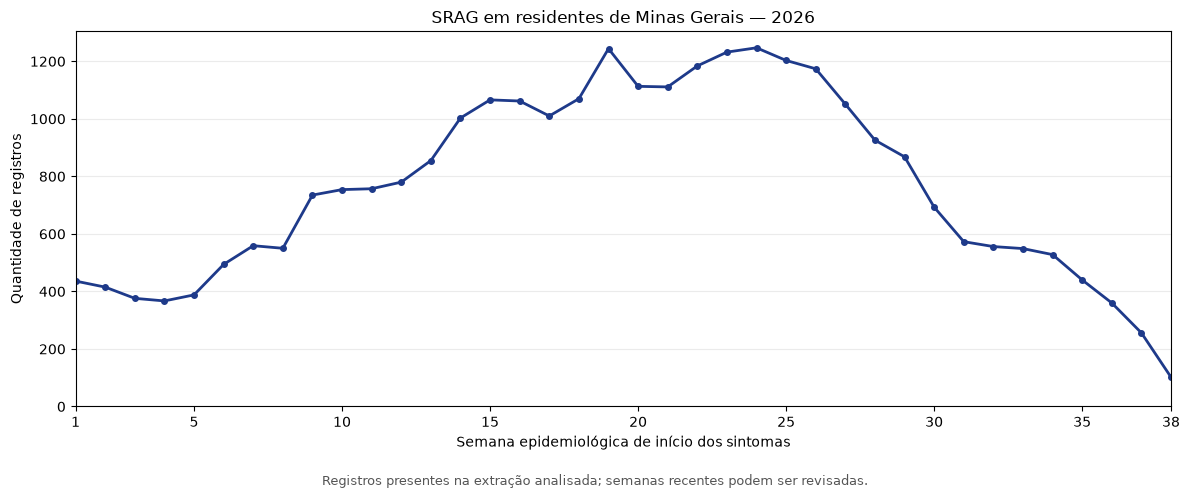

Gráfico salvo: /home/matheuspessoa/Sentinela/reports/figures/srag_2026_mg_weekly.png


In [49]:
import matplotlib.pyplot as plt

figure_dir = project_root / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

figure_path = figure_dir / "srag_2026_mg_weekly.png"

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekly_series["epi_week"],
    weekly_series["record_count"],
    color="#1e3a8a",
    marker="o",
    markersize=4,
    linewidth=2,
)

ax.set_title("SRAG em residentes de Minas Gerais — 2026")
ax.set_xlabel("Semana epidemiológica de início dos sintomas")
ax.set_ylabel("Quantidade de registros")

ax.set_xticks([1, *range(5, 39, 5), 38])
ax.set_xlim(1, 38)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)

fig.text(
    0.5,
    0.02,
    "Registros presentes na extração analisada; "
    "semanas recentes podem ser revisadas.",
    ha="center",
    fontsize=9,
    color="#555555",
)

fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(figure_path, dpi=150, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Gráfico salvo: {figure_path}")

## Série semanal de SRAG — Minas Gerais, 2026

A análise utiliza `data/processed/srag_2026_mg_v3.csv`,
com 29.087 registros de residentes de Minas Gerais.

Os registros foram agrupados pela semana epidemiológica de
início dos sintomas, utilizando `EPI_YEAR_CALCULATED` e
`EPI_WEEK_CALCULATED`.

### Resultados

- Intervalo observado: semanas 1 a 38 de 2026.
- Total: 29.087 registros.
- Maior contagem semanal: 1.247 registros na semana 24,
  de 14 a 20 de junho.
- A soma das contagens semanais foi conferida com o total da base.

### Limitações

As contagens representam os registros presentes na extração
analisada. As semanas recentes podem receber novas notificações
e revisões; a queda observada não demonstra, isoladamente,
uma redução real da ocorrência de SRAG.

Semanas posteriores à última semana com registros não foram
preenchidas com zero. Comparações entre anos dependem da
avaliação das respectivas bases.

### Saídas previstas

- `data/processed/srag_2026_mg_weekly.csv`
- `reports/figures/srag_2026_mg_weekly.png`

In [45]:
date_columns = [
    "DT_SIN_PRI_PARSED",
    "DT_NOTIFIC_PARSED",
]

date_coverage = []

for column in date_columns:
    dates = pd.to_datetime(analysis_df[column], errors="raise")

    date_coverage.append({
        "field": column,
        "first_date": dates.min(),
        "last_date": dates.max(),
        "missing_dates": int(dates.isna().sum()),
    })

display(pd.DataFrame(date_coverage))

,field,first_date,last_date,missing_dates
0,DT_SIN_PRI_PARSED,2026-01-04 00:00:00+00:00,2026-09-26 00:00:00+00:00,0
1,DT_NOTIFIC_PARSED,2026-01-04 00:00:00+00:00,2026-09-27 00:00:00+00:00,0


Validações concluídas:
✓ Soma semanal = 29087
✓ Acumulado final = 29087
✓ Semanas epidemiológicas únicas
✓ Períodos sem cobertura preservados como NA

In [50]:
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

weekly_path = processed_dir / "srag_2026_mg_weekly.csv"

week_series.to_csv(
    weekly_path,
    sep=";",
    index=False,
    encoding="utf-8",
    date_format="%Y-%m-%d",
)

print(f"Série semanal salva em: {weekly_path}")

Série semanal salva em: /home/matheuspessoa/Sentinela/data/processed/srag_2026_mg_weekly.csv


In [51]:
coverage_path = processed_dir / "srag_2026_mg_weekly_coverage.csv"

weekly_coverage.to_csv(
    coverage_path,
    sep=";",
    index=False,
    encoding="utf-8",
    date_format="%Y-%m-%d",
    na_rep="",
)

print(f"Cobertura semanal salva em: {coverage_path}")

Cobertura semanal salva em: /home/matheuspessoa/Sentinela/data/processed/srag_2026_mg_weekly_coverage.csv


In [52]:
exported_weekly = pd.read_csv(
    weekly_path,
    sep=";",
)

exported_coverage = pd.read_csv(
    coverage_path,
    sep=";",
)

assert len(exported_weekly) == len(weekly_series)
assert exported_weekly["record_count"].sum() == len(analysis_df)

assert len(exported_coverage) == 52
assert exported_coverage["epi_week"].is_unique

assert exported_coverage.loc[
    exported_coverage["epi_week"] == 38,
    "record_count",
].iloc[0] == 102

assert pd.isna(
    exported_coverage.loc[
        exported_coverage["epi_week"] == 39,
        "record_count",
    ].iloc[0]
)

assert pd.isna(
    exported_coverage.loc[
        exported_coverage["epi_week"] == 40,
        "record_count",
    ].iloc[0]
)

print("Exportação validada com sucesso.")
print(f"Total de registros: {exported_weekly['record_count'].sum():,.0f}")
print(f"Semanas observadas: {len(exported_weekly)}")
print(f"Semanas na tabela de cobertura: {len(exported_coverage)}")

Exportação validada com sucesso.
Total de registros: 29,087
Semanas observadas: 38
Semanas na tabela de cobertura: 52


In [54]:
symptom_dates = pd.to_datetime(
    analysis_df["DT_SIN_PRI_PARSED"],
    errors="raise",
    utc=True,
)

first_symptom_date = symptom_dates.min().date()
last_symptom_date = symptom_dates.max().date()

print("=" * 50)
print("RESUMO DA VALIDAÇÃO")
print("=" * 50)

print(f"Registros analisados: {len(analysis_df):,}")
print(
    f"Período observado: "
    f"{first_symptom_date} a {last_symptom_date}"
)
print(f"Semanas observadas: {len(weekly_series)}")
print(f"Última semana observada: {weekly_series['epi_week'].max()}")

print()
print("Arquivos gerados:")
print(f"- {weekly_path}")
print(f"- {coverage_path}")

print()
print("Validações:")
print("✓ Soma semanal confere com a base")
print("✓ Acumulado final confere com a base")
print("✓ Semanas epidemiológicas são únicas")
print("✓ Ausência de cobertura não foi convertida em zero")
print("✓ Arquivos exportados foram relidos e validados")

print()
print("Fonte atualizada em: 2026-09-28 00:47 (UTC-03:00)")
print("=" * 50)

RESUMO DA VALIDAÇÃO
Registros analisados: 29,087
Período observado: 2026-01-04 a 2026-09-26
Semanas observadas: 38
Última semana observada: 38

Arquivos gerados:
- /home/matheuspessoa/Sentinela/data/processed/srag_2026_mg_weekly.csv
- /home/matheuspessoa/Sentinela/data/processed/srag_2026_mg_weekly_coverage.csv

Validações:
✓ Soma semanal confere com a base
✓ Acumulado final confere com a base
✓ Semanas epidemiológicas são únicas
✓ Ausência de cobertura não foi convertida em zero
✓ Arquivos exportados foram relidos e validados

Fonte atualizada em: 2026-09-28 00:47 (UTC-03:00)
